# Utility code

In [1]:
import functools
import gc
import random
from abc import ABC, abstractmethod
from collections.abc import Sequence, Callable
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import torch
import torch.nn.functional as F
from gliner2 import GLiNER2
from huggingface_hub import get_token, login
from huggingface_hub.utils import disable_progress_bars
from sklearn.feature_extraction.text import CountVectorizer
from torchmetrics.functional.classification import binary_auroc
from transformers import AutoModelForSequenceClassification
from transformers import AutoTokenizer, AutoModel
from transformers.utils import logging as transformers_logging

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

generator = torch.Generator()
generator.manual_seed(42)

if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")

login()
print(DEVICE)

cuda


In [2]:
class TextEmbedder(ABC):
    @abstractmethod
    def embed(self, texts: Sequence[str]) -> torch.Tensor:
        raise NotImplementedError

    def __call__(self, texts: Sequence[str]) -> torch.Tensor:
        return self.embed(texts)


class _TransformerEncoder(TextEmbedder):
    model_name: str

    def __init__(
            self,
            *,
            device: torch.device = DEVICE,
            batch_size: int = 64
    ) -> None:
        self.device = device
        self.batch_size = batch_size
        self.model = self._load_model().to(self.device).eval()
        self.tokenizer = self._load_tokenizer()

    def _load_model(self) -> torch.nn.Module:
        return AutoModel.from_pretrained(self.model_name)

    def _load_tokenizer(self):
        return AutoTokenizer.from_pretrained(self.model_name)

    def _prepare_texts(self, texts: list[str]) -> list[str]:
        return texts

    @abstractmethod
    def _get_embeddings(self, batch: dict[str, torch.Tensor]) -> torch.Tensor:
        raise NotImplementedError

    def embed(self, texts: Sequence[str]) -> torch.Tensor:
        texts = list(texts)
        if not texts:
            raise ValueError("The input sequence is empty.")

        texts = self._prepare_texts(texts)
        embeddings = []

        with torch.inference_mode():
            for start in range(0, len(texts), self.batch_size):
                batch = self.tokenizer(
                    texts[start:start + self.batch_size],
                    padding="longest",
                    truncation=True,
                    return_tensors="pt",
                )
                batch = {name: tensor.to(self.device) for name, tensor in batch.items()}
                embeddings.append(self._get_embeddings(batch).cpu())

        return torch.cat(embeddings, dim=0).T.contiguous()


class _MeanPoolingEmbedder(_TransformerEncoder):

    def _get_last_hidden_state(self, batch: dict[str, torch.Tensor]) -> torch.Tensor:
        return self.model(**batch).last_hidden_state

    def _get_embeddings(self, batch: dict[str, torch.Tensor]) -> torch.Tensor:
        last_hidden_state = self._get_last_hidden_state(batch)
        mask = batch["attention_mask"].unsqueeze(-1).to(last_hidden_state.dtype)
        return (last_hidden_state * mask).sum(dim=1) / mask.sum(dim=1).clamp_min(1.0)


class EttinEncoder68M(_MeanPoolingEmbedder):
    model_name = "jhu-clsp/ettin-encoder-68m"


class MmBertSmall(_MeanPoolingEmbedder):
    model_name = "jhu-clsp/mmBERT-small"


class E5SmallV2(_MeanPoolingEmbedder):
    model_name = "intfloat/e5-small-v2"

    def _prepare_texts(self, texts: list[str]) -> list[str]:
        return [f"query: {text}" for text in texts]


class LlamaPromptGuard2MeanPooler(_MeanPoolingEmbedder):
    model_name = "meta-llama/Llama-Prompt-Guard-2-86M"

    def _load_model(self) -> torch.nn.Module:
        return AutoModelForSequenceClassification.from_pretrained(self.model_name)

    def _get_last_hidden_state(self, batch: dict[str, torch.Tensor]) -> torch.Tensor:
        return self.model.deberta(**batch).last_hidden_state


class LlamaPromptGuard2_86M(_TransformerEncoder):
    model_name = "meta-llama/Llama-Prompt-Guard-2-86M"

    def _load_model(self) -> torch.nn.Module:
        return AutoModelForSequenceClassification.from_pretrained(self.model_name)

    def _get_embeddings(self, batch: dict[str, torch.Tensor]) -> torch.Tensor:
        backbone_output = self.model.deberta(**batch)
        return self.model.pooler(backbone_output.last_hidden_state)


class GlinerGuardUniEncoder(_TransformerEncoder):
    model_name = "hivetrace/gliner-guard-uniencoder"

    def _load_model(self) -> torch.nn.Module:
        return GLiNER2.from_pretrained(self.model_name)

    def _load_tokenizer(self):
        return self.model.processor.tokenizer

    def _get_embeddings(self, batch: dict[str, torch.Tensor]) -> torch.Tensor:
        # GLiNER2 — это nn.Module: трансформерный бэкбон лежит в .encoder, задачные головы
        # не используются, берётся то же mean pooling, что и у остальных моделей.
        last_hidden_state = self.model.encoder(**batch).last_hidden_state
        mask = batch["attention_mask"].unsqueeze(-1).to(last_hidden_state.dtype)
        return (last_hidden_state * mask).sum(dim=1) / mask.sum(dim=1).clamp_min(1.0)


EMBEDDER_TYPES = {
    "ettin-encoder-68m": EttinEncoder68M,
    "mmBERT-small": MmBertSmall,
    "e5-small-v2": E5SmallV2,
    "Llama-Prompt-Guard-2-86M": LlamaPromptGuard2_86M,
    "Llama-Prompt-Guard-2-86M (mean pooler)": LlamaPromptGuard2MeanPooler,
    "gliner-guard-uniencoder": GlinerGuardUniEncoder
}

In [3]:
def describe(x: torch.Tensor, short: bool = False) -> dict[str, float]:
    x = x.detach().to(device=DEVICE, dtype=torch.float32)
    stat = {
        "mean": x.mean().item(),
        "std": x.std(unbiased=True).item(),
    }
    if short:
        return stat
    stat["25%"] = torch.quantile(x, 0.25).item()
    stat["50%"] = torch.quantile(x, 0.50).item()
    stat["75%"] = torch.quantile(x, 0.75).item()

    return stat


def display_table(
        statistic_method: Callable[..., dict[str, float | int]],
        name: str,
        stat_args_by_model: dict[str, tuple[Any, ...]] | None = None,
        **stat_args_by_group: dict[str, tuple[Any, ...]],
):
    if stat_args_by_model is not None:
        if not stat_args_by_model:
            raise ValueError("The input dictionary contains no models.")

        statistics_by_model = {
            model_name: statistic_method(*stat_args)
            for model_name, stat_args in stat_args_by_model.items()
        }
        table = pd.DataFrame.from_dict(statistics_by_model, orient="index")
        table.index.name = "embeddings"
        separator_selector = ""
    else:
        model_names = dict.fromkeys(
            model_name
            for args_by_model in stat_args_by_group.values()
            for model_name in args_by_model
        )
        if not model_names:
            raise ValueError("The input dictionaries contain no models.")

        statistics_by_model_and_group = {}
        for model_name in model_names:
            for group_name, stat_args in stat_args_by_group.items():
                statistics_by_model_and_group[(model_name, group_name)] = statistic_method(
                    *stat_args[model_name]
                )

        table = pd.DataFrame.from_dict(
            statistics_by_model_and_group,
            orient="index",
        )
        table.index = pd.MultiIndex.from_tuples(
            table.index,
            names=["embeddings", "group"],
        )

        separator_rows = [
            row_number
            for row_number, (previous, current) in enumerate(
                zip(table.index, table.index[1:]),
                start=2,
            )
            if previous[0] != current[0]
        ]
        separator_selector = ", ".join(
            f"tbody tr:nth-child({row}) > *"
            for row in separator_rows
        )

    formatters = {
        column: "{:d}" if pd.api.types.is_integer_dtype(table[column].dtype) else "{:.4f}"
        for column in table.columns
    }

    styles = [
        {
            "selector": "table",
            "props": [("border-collapse", "collapse")],
        },
        {
            "selector": "th, td",
            "props": [
                ("border", "1px solid #9aa5b1"),
                ("padding", "6px 10px"),
                ("text-align", "center"),
            ],
        },
        {
            "selector": "caption",
            "props": [
                ("font-weight", "bold"),
                ("text-align", "left"),
            ],
        },
    ]
    if separator_selector:
        styles.append({
            "selector": separator_selector,
            "props": [("border-top", "3px solid #4a5568")],
        })

    return (
        table
        .style
        .set_caption(name)
        .format(formatters)
        .background_gradient(cmap="Blues", axis=0)
        .set_table_styles(styles)
    )

In [4]:
def get_components_at_threshold(explained_variance: torch.Tensor, var_threshold: float = 0.9) -> int:
    cumulative_variance = explained_variance.cumsum(dim=0) / explained_variance.sum(dim=0)
    return int(torch.searchsorted(cumulative_variance, var_threshold).item()) + 1


def plot_pca_spectrum(
        calc_pca_decomposition: Callable[[torch.Tensor], tuple[torch.Tensor, torch.Tensor]],
        var_threshold: float = 0.9,
        **embeddings_by_sample: dict[str, torch.Tensor],
):
    if not embeddings_by_sample:
        raise ValueError("Pass at least one model-keyed input dictionary.")

    model_names = list(dict.fromkeys(
        model_name
        for embeddings_by_model in embeddings_by_sample.values()
        for model_name in embeddings_by_model
    ))
    if not model_names:
        raise ValueError("The input dictionaries contain no models.")
    sample_names = list(embeddings_by_sample)

    figure, axes = plt.subplots(
        nrows=len(model_names),
        ncols=len(sample_names),
        figsize=(5 * len(sample_names), 3.5 * len(model_names)),
        squeeze=False,
        sharey=False,
    )

    for row, model_name in enumerate(model_names):
        for column, sample_name in enumerate(sample_names):
            eigenvalues, _ = calc_pca_decomposition(embeddings_by_sample[sample_name][model_name])

            eigenvalues = (
                eigenvalues.detach()
                .to(device="cpu", dtype=torch.float64)
                .flatten()
            )
            if not torch.isfinite(eigenvalues).all():
                raise ValueError(
                    f"Eigenvalues must be finite for model {model_name!r}, dataset {sample_name!r}."
                )

            explained_variance = eigenvalues.clamp_min(0)
            total_variance = explained_variance.sum()
            if total_variance <= 0:
                raise ValueError(
                    f"Total variance must be positive for model {model_name!r}, dataset {sample_name!r}."
                )

            components_at_threshold = get_components_at_threshold(eigenvalues, var_threshold)

            component_numbers = np.arange(1, eigenvalues.numel() + 1)

            axis = axes[row, column]
            axis.plot(
                component_numbers,
                eigenvalues.numpy(),
                linewidth=1.5,
                marker="o",
                markersize=3,
            )
            axis.axvline(
                components_at_threshold,
                color="tab:red",
                linestyle="--",
                linewidth=1.25,
                label=f"{var_threshold * 100}% explained variance",
            )
            axis.annotate(
                str(components_at_threshold),
                xy=(components_at_threshold, 1.0),
                xycoords=("data", "axes fraction"),
                xytext=(4, -4),
                textcoords="offset points",
                color="tab:red",
                fontsize=12,
                rotation=90,
                va="top",
            )

            x_max = max(2, eigenvalues.numel(), components_at_threshold)
            x_padding = max(1, x_max * 0.05)
            axis.set_xlim(-x_padding, x_max)
            axis.margins(y=0.08)
            axis.locator_params(axis="y", nbins=6)
            axis.grid(alpha=0.25)
            axis.legend()

            if row == 0:
                axis.set_title(sample_name)
            if column == 0:
                axis.set_ylabel(f"{model_name}\nEigenvalue")
            if row == len(model_names) - 1:
                axis.set_xlabel("Component rank")

    figure.tight_layout()
    plt.close(figure)
    return figure

# Датасет и получение эмбеддингов



Анализ геометрии проведен на объединении трех датасетов с контрастивными парами benign/harmful промптов:

* [JailbreakBench Behaviors](https://huggingface.co/datasets/JailbreakBench/JBB-Behaviors)

* [FORTRESS](https://huggingface.co/datasets/ScaleAI/fortress_public)

In [5]:
MAX_PROMPT_CHARS = 15_000

DATASET_SOURCE_IDS = {
    "jbb_behaviors": 1,
    "fortress": 2,
}

# JailbreakBench Behaviors
jbb_harmful = pl.read_csv("hf://datasets/JailbreakBench/JBB-Behaviors/data/harmful-behaviors.csv",
                          storage_options={"token": get_token()})
jbb_benign = pl.read_csv("hf://datasets/JailbreakBench/JBB-Behaviors/data/benign-behaviors.csv",
                         storage_options={"token": get_token()})
jbb_pairs = (
    jbb_harmful
    .select("Index", pl.col("Goal").alias("harmful_prompt"))
    .join(
        jbb_benign.select("Index", pl.col("Goal").alias("benign_prompt")),
        on="Index",
        how="inner",
        validate="1:1",
    )
    .sort("Index")
    .select("harmful_prompt", "benign_prompt")
    .with_columns(pl.lit(DATASET_SOURCE_IDS["jbb_behaviors"]).alias("source_id"))
)

# FORTRESS
fortress = pl.read_parquet("hf://datasets/ScaleAI/fortress_public/data/train-00000-of-00001.parquet",
                           storage_options={"token": get_token()})
fortress_pairs = (
    fortress.select(
        pl.col("adversarial_prompt").alias("harmful_prompt"),
        pl.col("benign_prompt"),
    )
    .with_columns(pl.lit(DATASET_SOURCE_IDS["fortress"]).alias("source_id"))
)

# The union of two datasets
pairs = (
    pl.concat([fortress_pairs, jbb_pairs])
    .filter(
        (pl.col("harmful_prompt").str.len_chars() <= MAX_PROMPT_CHARS) & (
                pl.col("benign_prompt").str.len_chars() <= MAX_PROMPT_CHARS)
    )
    .with_row_index("pair_id")
    .sample(fraction=1.0, shuffle=True, seed=SEED)
)

HARMFUL = (
    pairs.select(
        pl.col("harmful_prompt").alias("prompt"),
        pl.lit(1).alias("label"),
        "source_id",
    )
)
BENIGN = (
    pairs.select(
        pl.col("benign_prompt").alias("prompt"),
        pl.lit(0).alias("label"),
        "source_id",
    )
)
DATASET_SOURCE_IDX = pairs["source_id"].to_torch()

## Расчет эмбеддингов



In [6]:
def get_embeddings(benign_dataset, harmful_dataset, embeddings_filename: str = "embeddings.pt"):
    try:
        embeddings = torch.load(embeddings_filename, weights_only=True)
    except FileNotFoundError:
        print("Getting embeddings from scratch...")
        embeddings = {}
    for model_name, embedder_type in EMBEDDER_TYPES.items():
        if model_name in embeddings:
            print(f"Embeddings for {model_name} are already computed")
            continue

        print(f"Loading {model_name}...")
        if model_name.startswith("Llama-Prompt-Guard-2"):
            embedder = embedder_type(batch_size=1)
        else:
            embedder = embedder_type(batch_size=4)

        print("Getting embeddings...")
        embeddings[model_name] = {
            "benign": embedder(benign_dataset["prompt"]),
            "harmful": embedder(harmful_dataset["prompt"]),
        }
        embeddings[model_name]["all"] = torch.cat((embeddings[model_name]["benign"], embeddings[model_name]["harmful"]),
                                                  dim=1)

        del embedder
        gc.collect()
        if DEVICE.type == "cuda":
            torch.cuda.empty_cache()

        torch.save(embeddings, embeddings_filename)
        print()

    return embeddings


disable_progress_bars()
transformers_logging.disable_progress_bar()
transformers_logging.set_verbosity_error()

EMBEDDINGS = get_embeddings(BENIGN, HARMFUL)

Embeddings for ettin-encoder-68m are already computed
Embeddings for mmBERT-small are already computed
Embeddings for e5-small-v2 are already computed
Embeddings for Llama-Prompt-Guard-2-86M are already computed
Embeddings for Llama-Prompt-Guard-2-86M (mean pooler) are already computed
Embeddings for gliner-guard-uniencoder are already computed


# Общая информация

In [7]:
def describe_embeddings(embeddings: torch.Tensor) -> dict[str, int]:
    return {
        "embeddings' dim": embeddings.shape[0],
        "number of samples": embeddings.shape[1],
        "mean l2-norm": embeddings.norm(p=2, dim=0).mean().item(),
    }


display_table(
    describe_embeddings,
    "Embeddings",
    benign={embedder: (EMBEDDINGS[embedder]["benign"],) for embedder in EMBEDDER_TYPES},
    harmful={embedder: (EMBEDDINGS[embedder]["harmful"],) for embedder in EMBEDDER_TYPES},
)

# Среднее и расстояния

In [8]:
def cos_similarity(x: torch.Tensor, y: torch.Tensor, dim: int = 0) -> torch.Tensor:
    x_norm = F.normalize(x, p=2, dim=dim)
    y_norm = F.normalize(y, p=2, dim=dim)

    return (x_norm * y_norm).sum(dim=dim)


def describe_mean_cos_distance(
        x: torch.Tensor,
        y: torch.Tensor,
        same_sample: bool = False,
        n: int = 100
) -> dict[str, float]:
    runs = []
    for _ in range(n):
        rand_perm = torch.randperm(x.shape[1], device=x.device)
        sample_size = rand_perm.shape[0]
        sample_x = x[:, rand_perm[:int(sample_size // 2)]].to(device=DEVICE)
        if same_sample:
            sample_y = y[:, rand_perm[int(sample_size // 2):]].to(device=DEVICE)
        else:
            sample_y = y[:, rand_perm[:int(sample_size // 2)]].to(device=DEVICE)

        runs.append(1 - cos_similarity(sample_x, sample_y).mean())

    return describe(torch.tensor(runs), short=True)


def describe_mean_l2_distance(
        x: torch.Tensor,
        y: torch.Tensor,
        same_sample: bool = False,
        n: int = 100,
) -> dict[str, float]:
    runs = []
    for _ in range(n):
        rand_perm = torch.randperm(x.shape[1], device=x.device)
        sample_size = rand_perm.shape[0]
        sample_x = x[:, rand_perm[:int(sample_size // 2)]].to(device=DEVICE)
        if same_sample:
            sample_y = y[:, rand_perm[int(sample_size // 2):]].to(device=DEVICE)
        else:
            sample_y = y[:, rand_perm[:int(sample_size // 2)]].to(device=DEVICE)

        runs.append((sample_x - sample_y).norm(p=2, dim=0).mean())

    return describe(torch.tensor(runs), short=True)


def calc_distance_ratio(x: torch.Tensor, y: torch.Tensor) -> dict[str, float]:
    x_center = x.mean(dim=1, keepdim=True)
    x_within_class_cos = describe_mean_cos_distance(x, x, same_sample=True)["mean"]
    x_within_class_l2 = describe_mean_l2_distance(x, x, same_sample=True)["mean"]

    y_center = y.mean(dim=1, keepdim=True)
    y_within_class_cos = describe_mean_cos_distance(y, y, same_sample=True)["mean"]
    y_within_class_l2 = describe_mean_l2_distance(y, y, same_sample=True)["mean"]

    return {
        "cosine": (2 * (1 - cos_similarity(x_center, y_center)) / (x_within_class_cos + y_within_class_cos)).item(),
        "L2": (2 * (x_center - y_center).norm(p=2) / (x_within_class_l2 + y_within_class_l2)).item()
    }


def describe_mean_distance(x: torch.Tensor, y: torch.Tensor, same_sample: bool = False, n: int = 100, ) -> dict[
    str, float]:
    cos = describe_mean_cos_distance(x, y, same_sample, n)
    l2 = describe_mean_l2_distance(x, y, same_sample, n)
    return {
        "cosine (mean)": cos["mean"],
        "cosine (std)": cos["std"],
        "L2 (mean)": l2["mean"],
        "L2 (std)": l2["std"],
    }

In [9]:
display_table(
    describe_mean_distance,
    "Mean distance (original embeddings)",
    within_benign={embedder: (EMBEDDINGS[embedder]["benign"], EMBEDDINGS[embedder]["benign"], True) for embedder in
                   EMBEDDER_TYPES},
    within_harmful={embedder: (EMBEDDINGS[embedder]["harmful"], EMBEDDINGS[embedder]["harmful"], True) for embedder in
                    EMBEDDER_TYPES},
    within_pair={embedder: (EMBEDDINGS[embedder]["benign"], EMBEDDINGS[embedder]["harmful"]) for embedder in
                 EMBEDDER_TYPES},
)

In [10]:
display_table(
    calc_distance_ratio,
    "Distance between class centers / mean within-class distance",
    {embedder: (EMBEDDINGS[embedder]["benign"], EMBEDDINGS[embedder]["harmful"]) for embedder in EMBEDDER_TYPES},
)

,cosine,L2
embeddings,,
ettin-encoder-68m,0.1050,0.3299
mmBERT-small,0.0721,0.2782
e5-small-v2,0.0435,0.1871
Llama-Prompt-Guard-2-86M,0.1375,0.9415
Llama-Prompt-Guard-2-86M (mean pooler),0.3299,0.6116
gliner-guard-uniencoder,0.0847,0.3491


# Дисперсия

In [11]:
def get_pca_decomposition(embeddings: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
    num_samples = embeddings.shape[1]
    embeddings_cnt = (embeddings - embeddings.mean(dim=1, keepdim=True))
    cov = (embeddings_cnt @ embeddings_cnt.T) / (num_samples - 1)
    values, vectors = torch.linalg.eigh(cov)
    return values.flip(0), vectors.flip(1)


def calc_pca_subspace_overlap(group_a: torch.Tensor, group_b: torch.Tensor, var_threshold: float = 0.9) -> dict[
    str, int | float]:
    # считаем PCA декомпозицию для ковариационных матриц
    group_a_values, group_a_vectors = get_pca_decomposition(group_a)
    group_b_values, group_b_vectors = get_pca_decomposition(group_b)

    # для каждого класса находим количество компонент, объясняющих var_threshold * 100 % вариативности в данных
    group_a_dim = get_components_at_threshold(group_a_values, var_threshold)
    group_b_dim = get_components_at_threshold(group_b_values, var_threshold)

    # берем направления, соответствующие найденным компонентам
    # они задают ортонормированный базис пространства в котором сосредоточено var_threshold * 100 % вариативности в данных
    a_basis = group_a_vectors[:, :group_a_dim]
    b_basis = group_b_vectors[:, :group_b_dim]

    # проецируем базисные вектора из пространства с меньшей размерностью в пространство с большей
    if group_a_dim < group_b_dim:
        projection = b_basis.T @ a_basis
    else:
        projection = a_basis.T @ b_basis

    # для простоты пусть всегда проецируем вектора-столбцы A в пространство span(B)
    # матрица projection по столбцам содержит координаты проекций векторов-столбцов A в базисе пространства span(B)
    # сингулярные числа этой матрицы показывают степень сжатия вектора из пространства span(A) при проекции в пространство span(B)
    singular_values = torch.linalg.svdvals(projection).flatten()

    return {
        "first subspace dim": group_a_dim,
        "second subspace dim": group_b_dim,

        # тут считается средняя доля квадрата длины вектора сохраняющаяся при проекции
        # если бы пространства были ортогональны, это значение близко к 0
        # если пространства полностью совпадают оно должно быть равно 1
        "subspace overlap": ((singular_values ** 2).sum() / min(group_a_dim, group_b_dim)).item()
    }

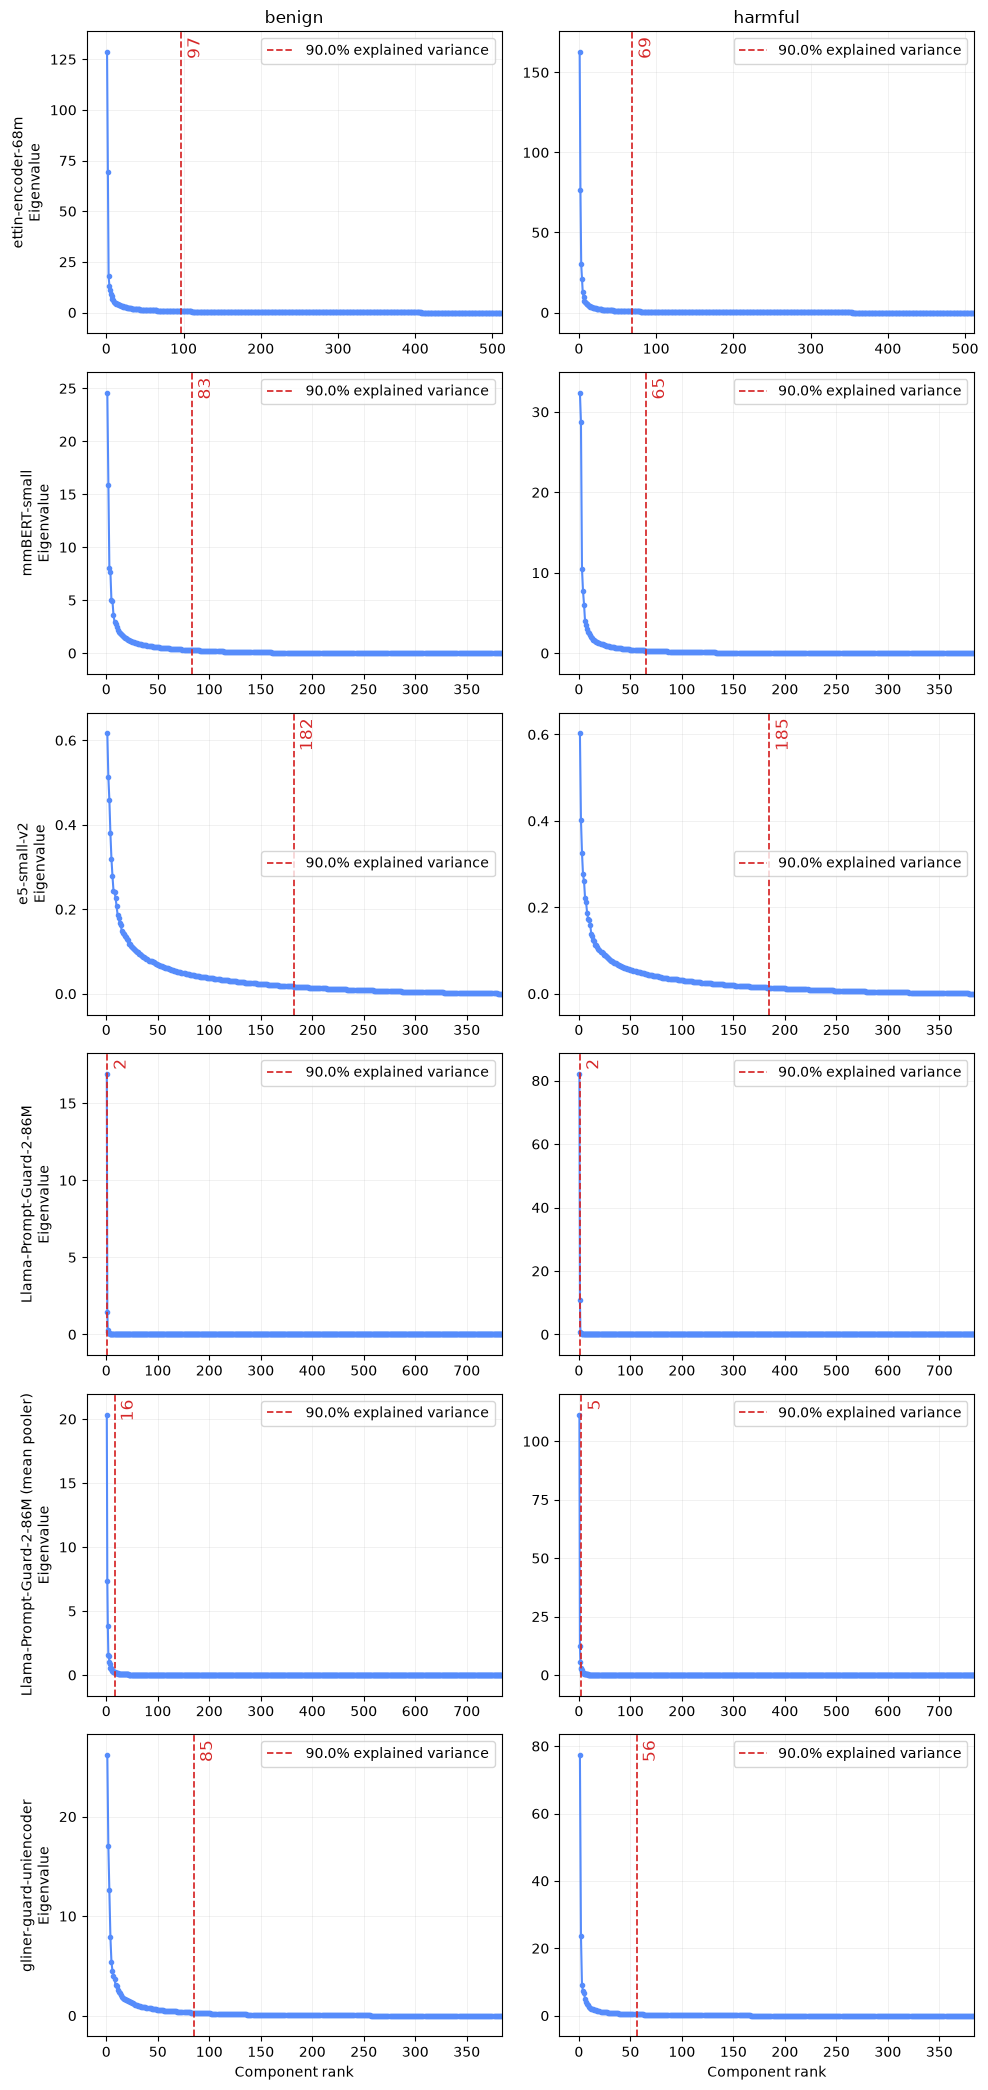

In [12]:
VAR_THRESHOLD = 0.9

plot_pca_spectrum(
    get_pca_decomposition,
    var_threshold=VAR_THRESHOLD,
    benign={embedder: EMBEDDINGS[embedder]["benign"] for embedder in EMBEDDER_TYPES},
    harmful={embedder: EMBEDDINGS[embedder]["harmful"] for embedder in EMBEDDER_TYPES}
)

In [13]:
display_table(
    functools.partial(calc_pca_subspace_overlap, var_threshold=VAR_THRESHOLD),
    f"Overlap at {VAR_THRESHOLD * 100:.0f}% of explained variance",
    {embedder: (EMBEDDINGS[embedder]["benign"], EMBEDDINGS[embedder]["harmful"]) for embedder in EMBEDDER_TYPES},
)

,first subspace dim,second subspace dim,subspace overlap
embeddings,,,
ettin-encoder-68m,97,69,0.7246
mmBERT-small,83,65,0.7676
e5-small-v2,182,185,0.6623
Llama-Prompt-Guard-2-86M,2,2,0.8909
Llama-Prompt-Guard-2-86M (mean pooler),16,5,0.9297
gliner-guard-uniencoder,85,56,0.7823


# Linear Probe

In [14]:
def train_linear_probe(
        x: torch.Tensor,
        y: torch.Tensor,
        val_frac: float = 0.1,
        lr: float = 1e-3,
        tol: float = 1e-5,
        early_stopping_iters: int = 100,
        max_iter_num: int = 10_000,
) -> torch.nn.Module:
    n = x.shape[0]
    val_size = int(n * val_frac)
    val_x = x[:val_size, :].to(device=DEVICE)
    val_y = y[:val_size, :].to(device=DEVICE)
    train_x = x[val_size:, :].to(device=DEVICE)
    train_y = y[val_size:, :].to(device=DEVICE)

    linear = torch.nn.Linear(train_x.shape[1], 1, device=DEVICE)
    optimizer = torch.optim.AdamW(linear.parameters(), lr=lr)

    best_val_loss = torch.inf
    best_state = None
    iterations_without_improvement = 0

    for i in range(1, max_iter_num + 1):
        linear.train()
        optimizer.zero_grad()
        train_loss = F.binary_cross_entropy_with_logits(linear(train_x), train_y)
        train_loss.backward()
        optimizer.step()

        linear.eval()
        with torch.no_grad():
            val_loss = F.binary_cross_entropy_with_logits(linear(val_x), val_y).item()

        if best_val_loss - val_loss > tol:
            best_val_loss = val_loss
            best_state = {
                name: value.detach().clone()
                for name, value in linear.state_dict().items()
            }
            iterations_without_improvement = 0
        else:
            iterations_without_improvement += 1
            if iterations_without_improvement >= early_stopping_iters:
                break

    if best_state is not None:
        linear.load_state_dict(best_state)

    return linear


def make_kfold_split(pairs_number: int, fold_num: int) -> list[dict[str, torch.Tensor]]:
    perm = torch.randperm(pairs_number)
    folds = torch.tensor_split(perm, fold_num)

    split_indices = []
    for test_fold_id in range(fold_num):
        test_indices = folds[test_fold_id]
        train_indices = []
        for train_fold_id in range(fold_num):
            if test_fold_id != train_fold_id:
                train_indices.append(folds[train_fold_id])
        train_indices = torch.cat(train_indices)
        split = {
            "test": test_indices,
            "train": train_indices,
        }
        split_indices.append(split)

    return split_indices


def describe_logistic_probe(benign: torch.Tensor, harmful: torch.Tensor, fold_num: int) -> dict[str, float]:
    folds = make_kfold_split(benign.shape[1], fold_num)

    def compose_datasets(idx: torch.Tensor, shuffle: bool = False):
        x = torch.cat([benign[:, idx], harmful[:, idx]], dim=1)
        y = torch.zeros(x.shape[1], dtype=torch.float).unsqueeze(0)
        y[:, idx.shape[0]:] = 1.0
        if shuffle:
            perm = torch.randperm(x.shape[1])
            return x[:, perm], y[:, perm]
        return x, y

    auroc = torch.zeros(fold_num)
    accuracy = torch.zeros(fold_num)
    for i, splits in enumerate(folds):
        train_x, train_y = compose_datasets(splits["train"], shuffle=True)
        test_x, test_y = compose_datasets(splits["test"])

        probe = train_linear_probe(train_x.T.contiguous(), train_y.T.contiguous()).eval()

        with torch.no_grad():
            test_x = test_x.T.to(device=DEVICE)
            test_y = test_y.T.to(device=DEVICE)
            test_logits = probe(test_x)

        auroc[i] = binary_auroc(test_logits.squeeze(1), test_y.squeeze(1).long()).item()
        accuracy[i] = ((test_logits.sigmoid() > 0.5) == test_y.bool()).float().mean().item()

    return {
        "auroc (mean)": auroc.mean().item(),
        "auroc (std)": auroc.std().item(),
        "accuracy (mean)": accuracy.mean().item(),
        "accuracy (std)": accuracy.std().item(),
    }

In [15]:
def make_kfold_split_text_data(
        benign: pl.DataFrame,
        harmful: pl.DataFrame,
        fold_num: int = 10
) -> list[dict[str, np.ndarray]]:
    assert benign.shape[0] == harmful.shape[0], "Size of both samples must match"
    assert fold_num - 1 < benign.shape[0], "Too small dataset"
    perm = torch.randperm(benign.shape[0])
    folds = torch.tensor_split(perm, fold_num)

    split_indices = []
    for test_fold_id in range(fold_num):
        test_indices = folds[test_fold_id]
        train_indices = []
        for train_fold_id in range(fold_num):
            if test_fold_id != train_fold_id:
                train_indices.append(folds[train_fold_id])
        train_indices = torch.cat(train_indices)
        split = {
            "test": test_indices.numpy(),
            "train": train_indices.numpy(),
        }
        split_indices.append(split)

    return split_indices


def test_linear_probe_on_bow(benign: pl.DataFrame, harmful: pl.DataFrame, fold_num: int):
    folds = make_kfold_split(benign.height, fold_num)

    def compose_dataset(idx: np.ndarray, shuffle: bool = False):
        dataset = pl.concat([benign[idx], harmful[idx]])
        if shuffle:
            return dataset.sample(fraction=1.0, shuffle=True, seed=SEED)
        return dataset

    auroc = torch.zeros(fold_num)
    accuracy = torch.zeros(fold_num)
    for i, splits in enumerate(folds):
        train_data = compose_dataset(splits["train"].numpy(), shuffle=True)
        test_data = compose_dataset(splits["test"].numpy())
        vectorizer = CountVectorizer(token_pattern=r"\w(?:\S*\w)?|[^\w\s]", lowercase=False, dtype=np.float32)

        train_bow_sparse = vectorizer.fit_transform(train_data["prompt"])
        train_x = torch.from_numpy(train_bow_sparse.toarray())
        train_y = train_data["label"].to_torch().float().unsqueeze(-1)
        probe = train_linear_probe(train_x, train_y).eval()

        test_bow_sparse = vectorizer.transform(test_data["prompt"])
        test_x = torch.from_numpy(test_bow_sparse.toarray())
        test_y = test_data["label"].to_torch().float().unsqueeze(-1)
        with torch.no_grad():
            test_x = test_x.to(device=DEVICE)
            test_y = test_y.to(device=DEVICE)
            test_logits = probe(test_x)

        auroc[i] = binary_auroc(test_logits.squeeze(1), test_y.squeeze(1).long()).item()
        accuracy[i] = ((test_logits.sigmoid() > 0.5) == test_y.bool()).float().mean().item()

    return {
        "auroc (mean)": auroc.mean().item(),
        "auroc (std)": auroc.std().item(),
        "accuracy (mean)": accuracy.mean().item(),
        "accuracy (std)": accuracy.std().item(),
    }


def test_linear_probe_on_prompt_len(benign: pl.DataFrame, harmful: pl.DataFrame, fold_num: int):
    folds = make_kfold_split(benign.height, fold_num)

    def compose_dataset(idx: np.ndarray, shuffle: bool = False):
        dataset = pl.concat([benign[idx], harmful[idx]]).select(pl.col("prompt").str.len_chars().alias("prompt_len"),
                                                                "label")
        if shuffle:
            return dataset.sample(fraction=1.0, shuffle=True, seed=SEED)
        return dataset

    auroc = torch.zeros(fold_num)
    accuracy = torch.zeros(fold_num)
    for i, splits in enumerate(folds):
        train_data = compose_dataset(splits["train"].numpy(), shuffle=True)
        test_data = compose_dataset(splits["test"].numpy())

        train_x = torch.from_numpy(train_data["prompt_len"].to_numpy()).float().unsqueeze(-1)
        train_y = train_data["label"].to_torch().float().unsqueeze(-1)
        probe = train_linear_probe(train_x, train_y).eval()

        test_x = torch.from_numpy(test_data["prompt_len"].to_numpy()).float().unsqueeze(-1)
        test_y = test_data["label"].to_torch().float().unsqueeze(-1)
        with torch.no_grad():
            test_x = test_x.to(device=DEVICE)
            test_y = test_y.to(device=DEVICE)
            test_logits = probe(test_x)

        auroc[i] = binary_auroc(test_logits.squeeze(1), test_y.squeeze(1).long()).item()
        accuracy[i] = ((test_logits.sigmoid() > 0.5) == test_y.bool()).float().mean().item()

    return {
        "auroc (mean)": auroc.mean().item(),
        "auroc (std)": auroc.std().item(),
        "accuracy (mean)": accuracy.mean().item(),
        "accuracy (std)": accuracy.std().item(),
    }


In [16]:
display_table(
    functools.partial(describe_logistic_probe, fold_num=50),
    "Linear probe (kfold cross validation)",
    {model: (EMBEDDINGS[model]["benign"], EMBEDDINGS[model]["harmful"]) for model in EMBEDDER_TYPES},
)

,auroc (mean),auroc (std),accuracy (mean),accuracy (std)
embeddings,,,,
ettin-encoder-68m,0.9167,0.0451,0.8386,0.0653
mmBERT-small,0.9115,0.0622,0.8353,0.0791
e5-small-v2,0.8950,0.0492,0.8268,0.0586
Llama-Prompt-Guard-2-86M,0.8943,0.0526,0.8154,0.0716
Llama-Prompt-Guard-2-86M (mean pooler),0.9176,0.0577,0.8313,0.0731
gliner-guard-uniencoder,0.9157,0.0493,0.8276,0.0789


In [17]:
display_table(
    functools.partial(test_linear_probe_on_bow, fold_num=50),
    "Linear probe (kfold cross validation)",
    {"BoW": (BENIGN, HARMFUL)},
)

,auroc (mean),auroc (std),accuracy (mean),accuracy (std)
embeddings,,,,
BoW,0.8696,0.0677,0.7059,0.1285


In [18]:
display_table(
    functools.partial(test_linear_probe_on_prompt_len, fold_num=50),
    "Linear probe (kfold cross validation)",
    {"prompt len in chars": (BENIGN, HARMFUL)},
)

,auroc (mean),auroc (std),accuracy (mean),accuracy (std)
embeddings,,,,
prompt len in chars,0.7904,0.0744,0.6733,0.1022


# Fisher discriminant ratio для найденного направления

In [19]:
def calc_fisher_discriminant_ratio(benign: torch.Tensor, harmful: torch.Tensor, fold_num: int) -> dict[str, float]:
    folds = make_kfold_split(benign.shape[1], fold_num)

    def compose_datasets(idx: torch.Tensor, shuffle: bool = False):
        x = torch.cat([benign[:, idx], harmful[:, idx]], dim=1)
        y = torch.zeros(x.shape[1], dtype=torch.float).unsqueeze(0)
        y[:, idx.shape[0]:] = 1.0
        if shuffle:
            perm = torch.randperm(x.shape[1])
            return x[:, perm], y[:, perm]
        return x, y

    fdr = torch.zeros(fold_num)
    for i, splits in enumerate(folds):
        train_x, train_y = compose_datasets(splits["train"], shuffle=True)
        test_x, test_y = compose_datasets(splits["test"])

        probe = train_linear_probe(train_x.T.contiguous(), train_y.T.contiguous()).eval()

        with torch.no_grad():
            test_x = test_x.T.to(device=DEVICE)
            test_y = test_y.T.to(device=DEVICE)
            test_logits = probe(test_x)

        first_class = test_logits[test_y.bool()]
        second_class = test_logits[~test_y.bool()]

        fdr[i] = (first_class.mean() - second_class.mean()) ** 2 / (first_class.var() + second_class.var())

    return {
        "FDR (mean)": fdr.mean().item(),
        "FDR (std)": fdr.std().item(),
    }

In [20]:
display_table(
    functools.partial(calc_fisher_discriminant_ratio, fold_num=3),
    "FDR for linear probe direction (kfold cross validation)",
    {model: (EMBEDDINGS[model]["benign"], EMBEDDINGS[model]["harmful"]) for model in EMBEDDER_TYPES},
)

,FDR (mean),FDR (std)
embeddings,,
ettin-encoder-68m,1.8927,0.1327
mmBERT-small,1.7005,0.1740
e5-small-v2,1.4014,0.0971
Llama-Prompt-Guard-2-86M,1.1291,0.1239
Llama-Prompt-Guard-2-86M (mean pooler),1.6859,0.1217
gliner-guard-uniencoder,1.8122,0.1512
